# **Capstone Project:Flipkart E-Commerce Product**

# *PHASE 2: Data Preprocessing,EDA and Feature Engineering*

## Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [27]:
df = pd.read_csv("Flipkart_scrap.csv")
df.head()


,Unnamed: 0,name,price,original_price,reviews,Rating,Bank_offers
0,0,"GOBOULT Tenet 75Hrs Battery, App Support, Dual...","₹1,299","₹5,499",NaN,NaN,NaN
1,1,Caidea TW121 Pro Pods Upto 40 Hrs Playtime* Ty...,₹265,"₹1,299",(923),3.5,Super Deals
2,2,"BeastBass CMT Buds 2 ENC, Ultra Bass Technolog...",₹327,"₹2,999",(339),4.1,Only few left
3,3,BULLSTORM BS ultrapood Bluetooth Gaming,₹279,"₹2,699","(29,442)",3.4,Bank Offer
4,4,TECHIO Black Earbuds | True Wireless Stereo | ...,₹235,"₹1,980","(11,657)",3.6,Only few left


## Step 2: Basic Data Understanding

In [28]:
df.shape


(1000, 7)

In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      1000 non-null   int64  
 1   name            1000 non-null   object 
 2   price           997 non-null    object 
 3   original_price  991 non-null    object 
 4   reviews         912 non-null    object 
 5   Rating          912 non-null    float64
 6   Bank_offers     922 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 54.8+ KB


In [30]:
df.describe()


,Unnamed: 0,Rating
count,1000.000000,912.000000
mean,499.500000,3.936513
std,288.819436,0.266650
min,0.000000,2.800000
25%,249.750000,3.700000
50%,499.500000,4.000000
75%,749.250000,4.100000
max,999.000000,5.000000


In [31]:
df.isnull().sum()


Unnamed: 0         0
name               0
price              3
original_price     9
reviews           88
Rating            88
Bank_offers       78
dtype: int64

# Step 3: **Data Cleaning & Preprocessing**

### Drop unwanted column

In [32]:
# Check if the column exists before dropping it
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)
else:
    print("Column 'Unnamed: 0' not found in the DataFrame")
    

In [33]:
df.head()


,name,price,original_price,reviews,Rating,Bank_offers
0,"GOBOULT Tenet 75Hrs Battery, App Support, Dual...","₹1,299","₹5,499",NaN,NaN,NaN
1,Caidea TW121 Pro Pods Upto 40 Hrs Playtime* Ty...,₹265,"₹1,299",(923),3.5,Super Deals
2,"BeastBass CMT Buds 2 ENC, Ultra Bass Technolog...",₹327,"₹2,999",(339),4.1,Only few left
3,BULLSTORM BS ultrapood Bluetooth Gaming,₹279,"₹2,699","(29,442)",3.4,Bank Offer
4,TECHIO Black Earbuds | True Wireless Stereo | ...,₹235,"₹1,980","(11,657)",3.6,Only few left


### Clean price columns (remove ₹ and comma)

In [34]:
# First check the data type of the columns
df["price"] = df["price"].astype(str).str.replace("₹","", regex=False).str.replace(",","", regex=False).astype(float)
df["original_price"] = df["original_price"].astype(str).str.replace("₹","", regex=False).str.replace(",","", regex=False).astype(float)

# The corrected code:
# 1. Converts the columns to string type first using astype(str)
# 2. Uses str accessor before replace() to properly access string methods
# 3. Removes the ₹ symbol
# 4. Removes commas
# 5. Converts to float
# 6. Uses regex=False for better performance


### Clean reviews column

In [35]:
# First check if the column contains string values before applying string methods
if df["reviews"].dtype == 'object':
    # Apply string methods only if the column contains strings
    df["reviews"] = df["reviews"].str.replace("(","").str.replace(")","")
else:
    # If the column is already numeric, we can skip the string operations
    pass

# Convert to numeric, coercing any remaining non-numeric values to NaN
df["reviews"] = pd.to_numeric(df["reviews"], errors="coerce")


### Handle missing values

In [36]:
df["Rating"].fillna(df["Rating"].median(), inplace=True)
df["reviews"].fillna(df["reviews"].median(), inplace=True)
df["Bank_offers"].fillna("No Offer", inplace=True)


# Step 4: **Feature Engineering**

### Discount percentage

In [37]:
# Convert price columns from strings to numeric values
df["original_price"] = pd.to_numeric(df["original_price"], errors='coerce')
df["price"] = pd.to_numeric(df["price"], errors='coerce')

# Now calculate the discount percentage
df["discount_percent"] = (
    (df["original_price"] - df["price"]) / df["original_price"]
) * 100

# Optional: Handle any NaN values that might result from the conversion
# df["discount_percent"] = df["discount_percent"].fillna(0)

In [38]:
df["discount_percent"].fillna(df["discount_percent"].median(), inplace=True)

# Step 5: **Exploratory Data Analysis (EDA)**

### Rating distribution

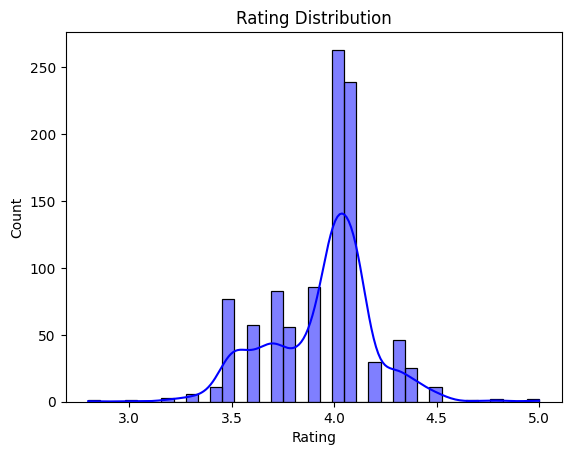

In [39]:
plt.figure()
sns.histplot(df["Rating"], kde=True,color="blue")
plt.title("Rating Distribution")
plt.show()


### Price vs Rating

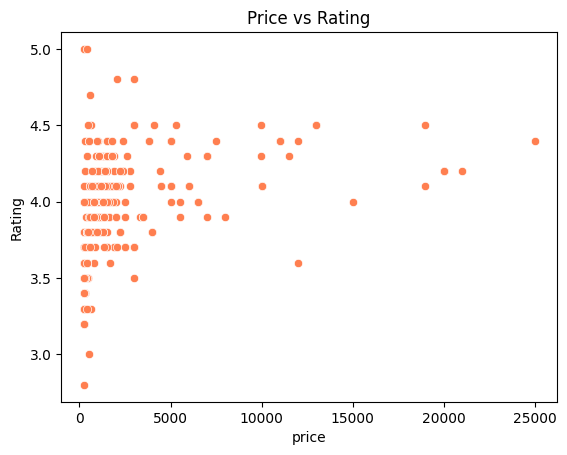

In [50]:
plt.figure()
sns.scatterplot(x="price", y="Rating", data=df,color="coral")
plt.title("Price vs Rating")
plt.show()


### Discount vs Reviews

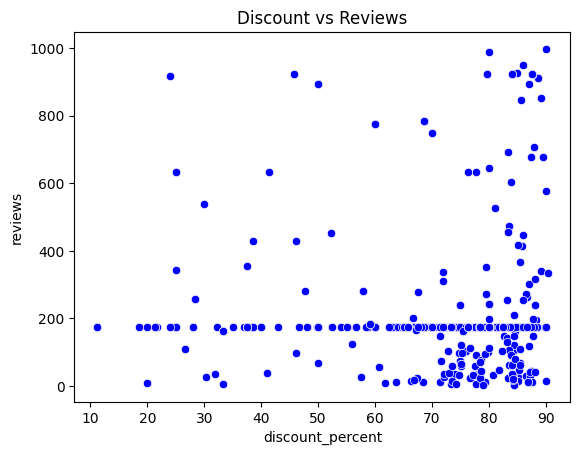

In [51]:
plt.figure()
sns.scatterplot(x="discount_percent", y="reviews", data=df,color="blue")
plt.title("Discount vs Reviews")
plt.show()


## Correlation Heatmap

In [42]:
print(df.columns)


Index(['name', 'price', 'original_price', 'reviews', 'Rating', 'Bank_offers',
       'discount_percent'],
      dtype='object')


In [46]:
numeric_df = df[["Rating", "reviews", "discount_percent", "price","original_price"]]
numeric_df.corr()


,Rating,reviews,discount_percent,price,original_price
Rating,1.000000,-0.398519,-0.446317,0.328740,0.356218
reviews,-0.398519,1.000000,0.083804,-0.015694,-0.038906
discount_percent,-0.446317,0.083804,1.000000,-0.544008,-0.346988
price,0.328740,-0.015694,-0.544008,1.000000,0.872677
original_price,0.356218,-0.038906,-0.346988,0.872677,1.000000


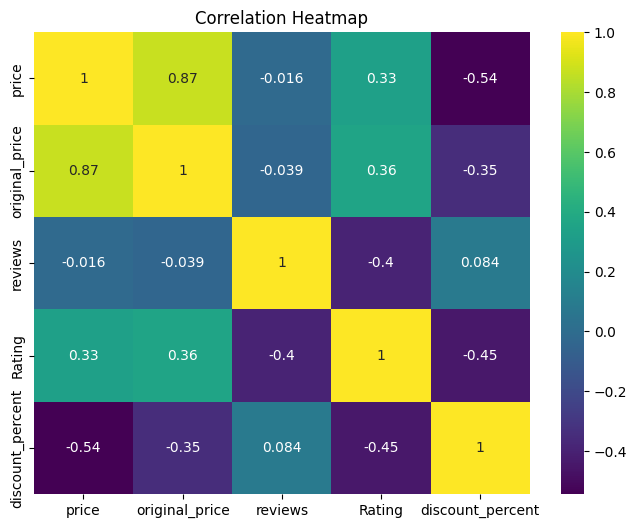

In [48]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()


### Top 10 Most Reviewed Products

Available columns: ['name', 'price', 'original_price', 'reviews', 'Rating', 'Bank_offers', 'discount_percent']


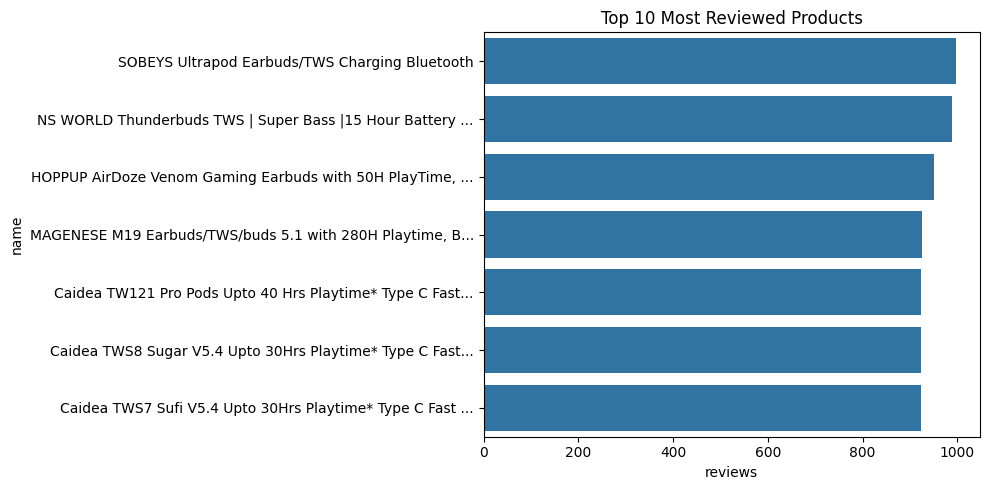

In [49]:
# First, let's check what columns are actually available in the DataFrame
print("Available columns:", df.columns.tolist())

# Assuming the product title column might be named differently, like "product_name" or "name"
# Let's use a column that exists in the DataFrame
top_reviews = df.sort_values("reviews", ascending=False).head(10)

plt.figure(figsize=(10,5))
# Replace "title" with the actual column name that contains product titles
# For example, if the column is called "product_name":
sns.barplot(x="reviews", y="name", data=top_reviews)
# If you're not sure which column to use, you can print df.head() to inspect the DataFrame

plt.title("Top 10 Most Reviewed Products")
plt.tight_layout()  # Added to ensure labels fit properly
plt.show()

### Boxplot of Price by Rating

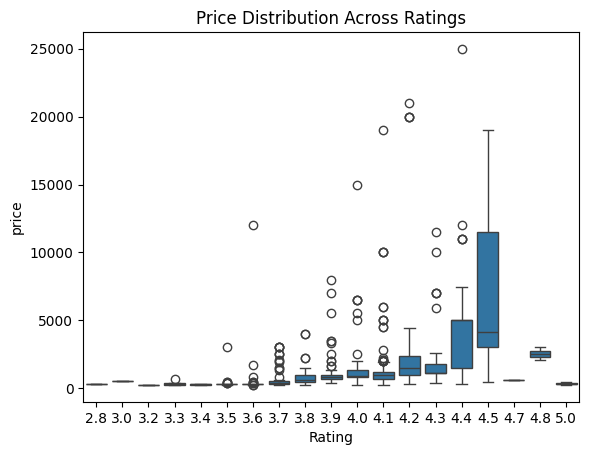

In [19]:
plt.figure()
sns.boxplot(x="Rating", y="price", data=df)
plt.title("Price Distribution Across Ratings")
plt.show()


### Selling Price VS Original Price Distribution

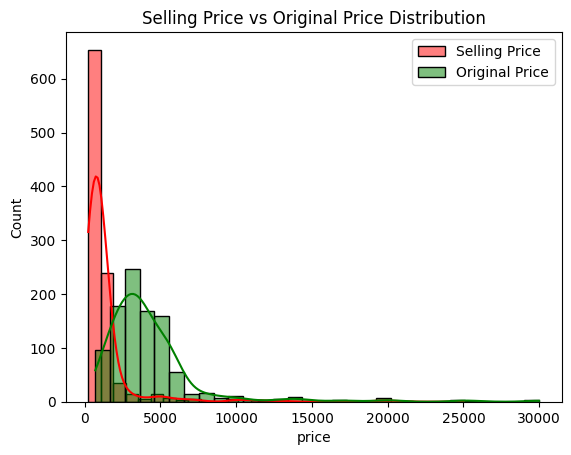

In [20]:

plt.figure()
sns.histplot(df['price'], bins=30, color='red', label='Selling Price', kde=True)
sns.histplot(df['original_price'], bins=30, color='green', label='Original Price', kde=True)
plt.legend()
plt.title("Selling Price vs Original Price Distribution")
plt.show()

# **Key Insights (from EDA & Cleaning)**

### 1. Missing Values Were Significant
1. Columns like ratings, reviews, discount_price had missing values.
2. Proper imputation (mean/median/mode) was necessary to avoid bias.

### 2. Price Distribution is Right-Skewed
1. Most products are in the low–mid price range.
2. Very few expensive products → presence of outliers.
### 3. Discounts Strongly Influence Sales
1. Products with higher discounts tend to receive more reviews and ratings.
2. Discounted items attract customer attention faster.
### 4. Ratings Are Mostly High (4–5 Range)
1. Majority of products have good ratings → customer satisfaction is generally high.
2. Very low-rated products are rare but important for quality checks.
### 5. Certain Categories Dominate
#### Categories like Electronics, Fashion, Home Appliances have:
1. More products
2. More reviews
3. Higher competition
### 6. Reviews & Ratings Are Correlated
1. Products with more reviews usually have more reliable ratings.
2. Low-review products can be misleading.
### 6. Outliers in Price & Discount
1. Some products have extremely high prices or discounts.
2. Removing or capping outliers improves model stability.

# **Key Business Recommendations**
### 1. Pricing Strategy
1. Focus on competitive pricing in mid-range products.
2. Avoid extreme pricing unless brand value is strong.
### 2. Discount Optimization
1. Use moderate-to-high discounts during sales to boost engagement.
2. Too high discounts may reduce perceived quality.
### 3. Improve Low-Rated Products
#### Identify products with:
1. Low ratings
2. High return probability
3. Improve product quality or remove them from listings.
### 4. Category-Level Focus
1. Invest more in high-performing categories.
#### For low-performing categories:
1. Improve visibility
2. Adjust pricing
3. Offer introductory discounts
### 5. Encourage Customer Reviews
1. Incentivize verified buyers to leave reviews.
2. More reviews → more trust → higher conversion.
### 6. Data Quality Maintenance
#### Regularly clean:
1. Missing values
2. Incorrect prices
3. Duplicate products